Dataset loaded successfully!

Data cleaned successfully!

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


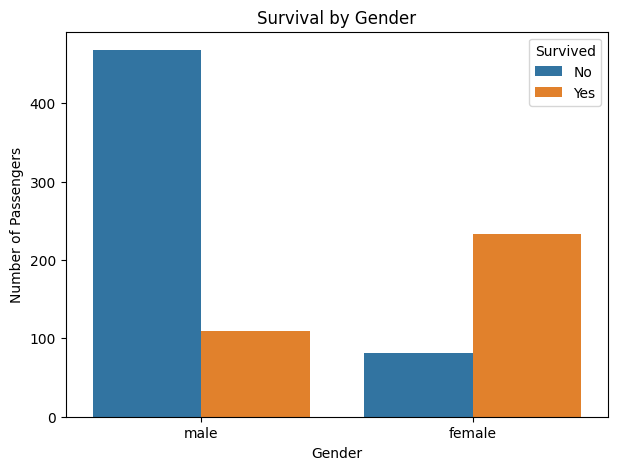

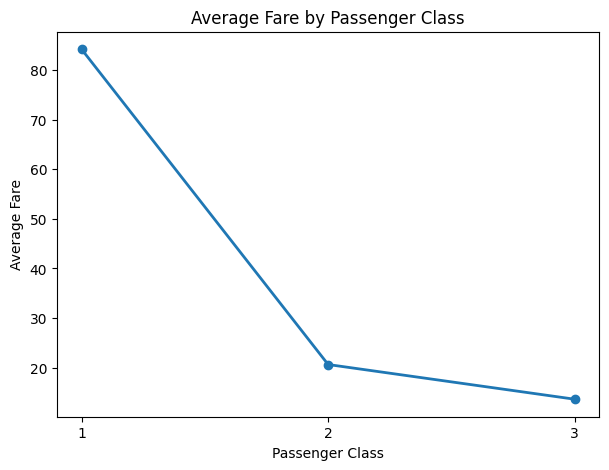

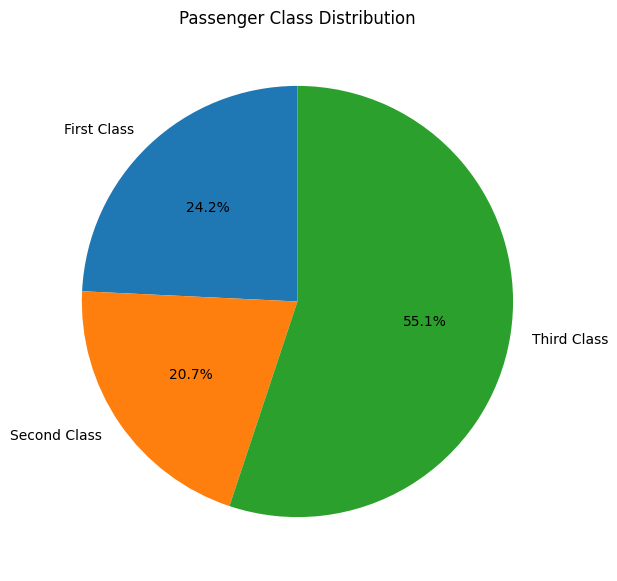

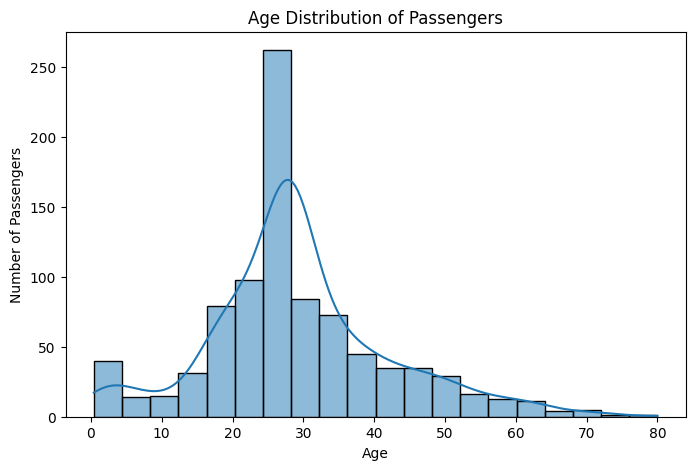

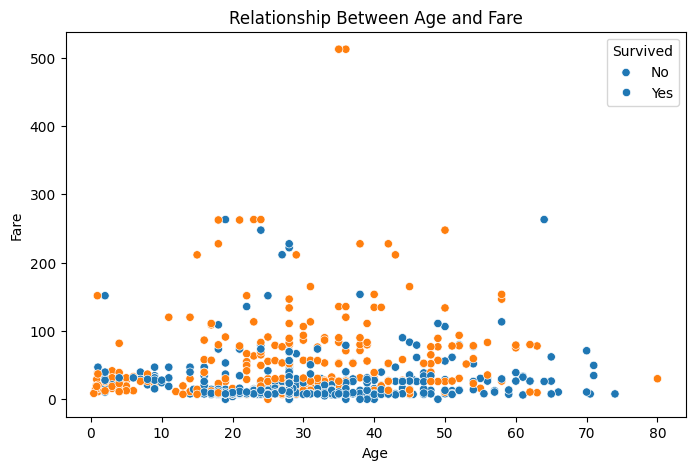

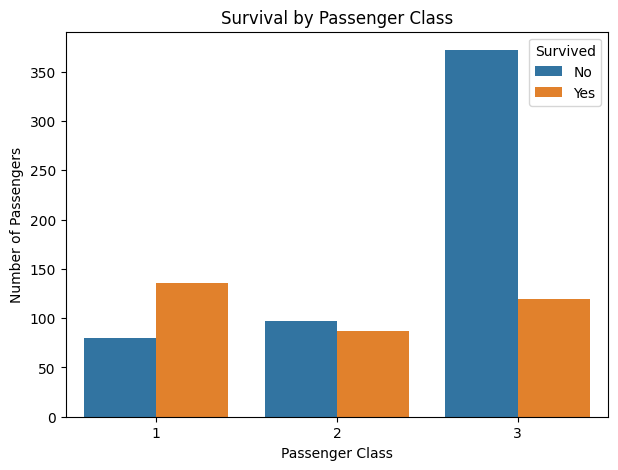


KEY VISUALIZATION INSIGHTS

Survival by Gender:
Survived    0    1
Sex               
female     81  233
male      468  109

Survival by Passenger Class:
Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119

Average Fare by Passenger Class:
Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

Average Passenger Age:
29.36158249158249

Total Passengers:
891

Visualization completed successfully!


In [4]:
# ============================================
# PROGRAM 3
# DATA VISUALIZATION
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# 1. LOAD TITANIC DATASET
# ============================================

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")

# ============================================
# 2. CLEAN THE DATA
# ============================================

# Fill missing Age values with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Remove duplicate records
df = df.drop_duplicates()

print("\nData cleaned successfully!")

print("\nMissing values:")
print(df.isnull().sum())


# ============================================
# 3. BAR CHART - SURVIVAL BY GENDER
# ============================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Sex",
    hue="Survived"
)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.show()


# ============================================
# 4. LINE CHART - AVERAGE FARE BY CLASS
# ============================================

average_fare = df.groupby("Pclass")["Fare"].mean()

plt.figure(figsize=(7, 5))

plt.plot(
    average_fare.index,
    average_fare.values,
    marker="o",
    linewidth=2
)

plt.title("Average Fare by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Fare")
plt.xticks([1, 2, 3])

plt.show()


# ============================================
# 5. PIE CHART - PASSENGER CLASS DISTRIBUTION
# ============================================

class_counts = df["Pclass"].value_counts().sort_index()

plt.figure(figsize=(7, 7))

plt.pie(
    class_counts.values,
    labels=["First Class", "Second Class", "Third Class"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Passenger Class Distribution")

plt.show()


# ============================================
# 6. HISTOGRAM - AGE DISTRIBUTION
# ============================================

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Age"],
    bins=20,
    kde=True
)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()


# ============================================
# 7. SCATTER PLOT - AGE VS FARE
# ============================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Fare",
    hue="Survived"
)

plt.title("Relationship Between Age and Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.show()


# ============================================
# 8. EXTRA BAR CHART - SURVIVAL BY CLASS
# ============================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Pclass",
    hue="Survived"
)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.show()


# ============================================
# 9. KEY INSIGHTS
# ============================================

print("\n================================")
print("KEY VISUALIZATION INSIGHTS")
print("================================")

print("\nSurvival by Gender:")
print(pd.crosstab(df["Sex"], df["Survived"]))

print("\nSurvival by Passenger Class:")
print(pd.crosstab(df["Pclass"], df["Survived"]))

print("\nAverage Fare by Passenger Class:")
print(average_fare)

print("\nAverage Passenger Age:")
print(df["Age"].mean())

print("\nTotal Passengers:")
print(len(df))

print("\nVisualization completed successfully!")